# EPSP ratio comparison with Sjostrom and Hausser 2006 dataset

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference == "Sjostrom and Hausser 2006"]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
40,sjh06_01,L5TTPC,L5TTPC,VC,rat,P14 - P21,50.0,10,5,15,10,1.40,0.06,34,Sjostrom and Hausser 2006,Nothing.,0.349857
41,sjh06_02,L23PC,L5TTPC,VC,rat,P14 - P21,50.0,10,5,15,10,1.06,0.09,19,Sjostrom and Hausser 2006,Nothing.,0.392301


In [2]:
# Load Sjostrom and Hausser 2006 data
insilico_exp, insilico_out, insilico = load_insilico('data/insilico/sjostrom_hausser_2006/L23PC_L5TTPC.csv')

No outliers in data/insilico/sjostrom_hausser_2006/L23PC_L5TTPC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
1431,26984,138611,30.0,50,0.936878,0.600473
445,10322,136147,50.0,-10,0.532443,1.986819
2817,17527,158163,10.0,50,2.704152,0.086563
4810,4654,138464,2.0,-50,0.814890,0.256653
2470,4462,155325,20.0,10,0.831223,2.639755


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,0.935605,0.157605,0.015760,100
1,2.0,-30,0.897604,0.179249,0.017925,100
2,2.0,-10,0.897660,0.254994,0.025499,100
3,2.0,5,1.013137,0.474355,0.047435,100
4,2.0,10,0.991775,0.465643,0.046564,100
5,2.0,30,0.976130,0.404485,0.040448,100
6,2.0,50,0.960459,0.408156,0.040816,100
7,5.0,-50,0.887896,0.328798,0.032880,100
8,5.0,-30,0.896707,0.321424,0.032142,100
9,5.0,-10,0.862597,0.297500,0.029750,100


t-test results for frequency_train = 50.000000: s = 1.174, p = 0.245


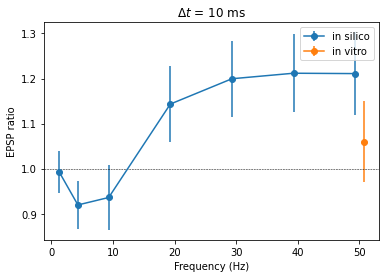

In [3]:
# Plot LTP freq
sel_invitro = invitro[invitro.pre_mtype=='L23PC']
sel_insilico = insilico[insilico.dt_train==10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
ax.set_title(r'$\Delta t$ = 10 ms');
#fig.savefig('l23_l5_ltp.svg')

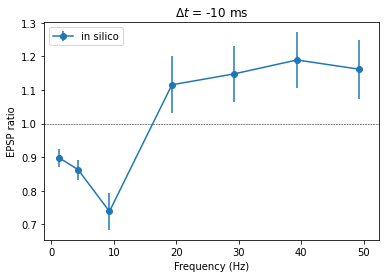

In [4]:
# Plot LTD freq
sel_insilico = insilico[insilico.dt_train==-10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico')
ax.legend(loc=2)
ax.set_title(r'$\Delta t$ = -10 ms');
#fig.savefig('l23_l5_ltd.svg')

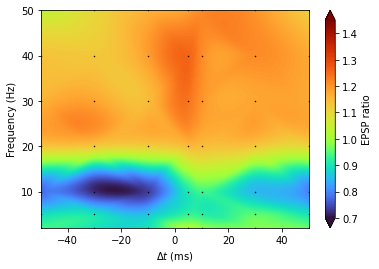

In [5]:
# Plot map
mapsize = np.array((6.2, 4.8))/3 if pubstyle else None
fig = plot_map(insilico, mapsize=mapsize)
#fig.savefig('l23_l5_map.svg')

in silico fit params: 1.22 (+/- 0.06) x ^ -0.32 (+/- 0.13)
in vitro fit params: 1.61 (+/- 0.04) x ^ -0.41 (+/- 0.04)


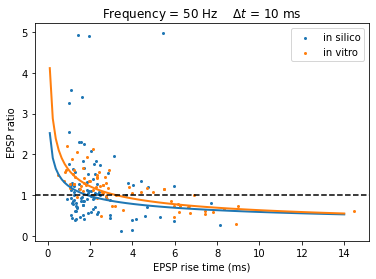

In [6]:
# Distance-dependent plastiticy
sel_insilico = insilico_exp[(insilico_exp.frequency_train==50.) & (insilico_exp.dt_train==10.)]
sel_insilico.to_csv('data/insilico/plast_vs_dist.csv',
                    columns=['epsp_ratio', 'risetime'], index=False)  # For stats with R
sel_invitro = pd.read_csv('data/invitro/plast_vs_dist_sjostrom_hausser_2006.csv')

x = np.linspace(0.1, 14, 100)

fig, ax = plt.subplots()

# Fit power law to insilico data
popt, perr = fit_powerlaw(sel_insilico.risetime, sel_insilico.epsp_ratio)
print('in silico fit params: %.2f (+/- %.2f) x ^ %.2f (+/- %.2f)' % (popt[0], perr[0], popt[1], perr[1]))
ax.scatter(sel_insilico.risetime, sel_insilico.epsp_ratio, s=4, alpha=1, marker='o', c='C0', label='in silico')
ax.plot(x, powerlaw(x, *popt), lw=2, c='C0')

# Fit power law to invitro data
popt, perr = fit_powerlaw(sel_invitro.risetime, sel_invitro.epsp_ratio/100)
print('in vitro fit params: %.2f (+/- %.2f) x ^ %.2f (+/- %.2f)' % (popt[0], perr[0], popt[1], perr[1]))
ax.scatter(sel_invitro.risetime, sel_invitro.epsp_ratio/100., s=4, alpha=1, marker='o', c='C1', label='in vitro')
ax.plot(x, powerlaw(x, *popt), lw=2, c='C1')

ax.axhline(1, c='k', ls='dashed')
ax.set_ylabel('EPSP ratio')
ax.set_xlabel('EPSP rise time (ms)')
ax.legend()
ax.set_title(r'Frequency = 50 Hz    $\Delta t$ = 10 ms');
#fig.savefig('l23_l5_distance.svg')

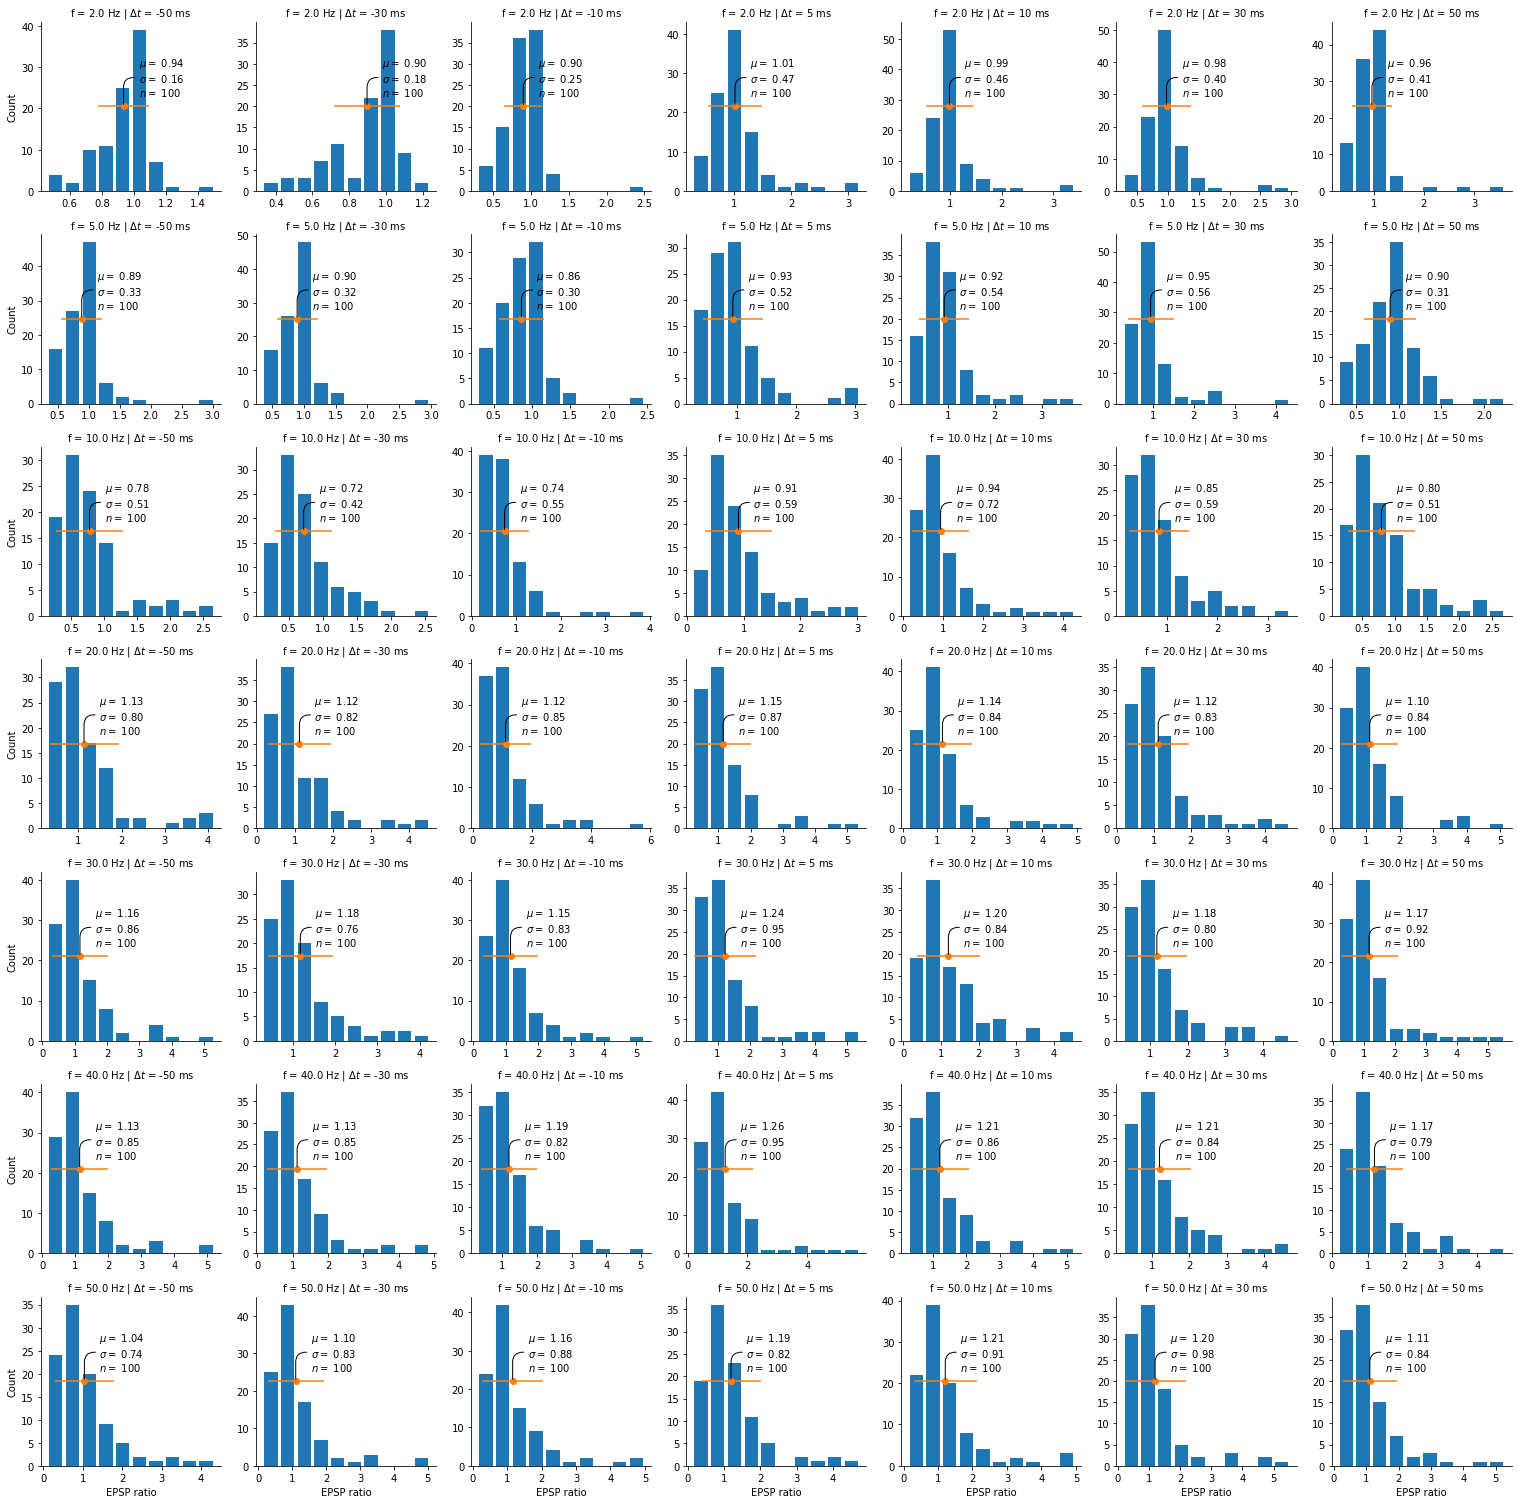

In [7]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l23_l5_sjh06_hist.png", dpi=300)